PART A

QUESTION 1.a

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gdp # IMPORTING GEOPANDAS LIBRARY

In [2]:
land_parcels = gdp.read_file('land_parcels.geojson') #LOADING LAND PARCELS
land_parcels.head() # PRINTING FIRST 5 ROWS

,parcel_id,owner_name,land_use,tenure_type,area_m2,area_ha,reg_year,district,region,value_GHS,centroid_lon,centroid_lat,registered,geometry
0,TWKP-0001,Kweku Quaye,Agricultural,Leasehold,172733.1,17.2733,2003,Tarkwa-Nsuaem,Western,1.359340e+07,-1.988151,5.301906,True,"POLYGON ((-1.99 5.3, -1.9863 5.3, -1.9863 5.30..."
1,TWKP-0002,Akua Asante,Residential,Customary,125985.3,12.5985,2014,Tarkwa-Nsuaem,Western,3.848290e+07,-1.984029,5.301636,True,"POLYGON ((-1.9856 5.3, -1.98246 5.3, -1.98246 ..."
2,TWKP-0003,Esi Boateng,Commercial,Freehold,131690.3,13.1690,2012,Tarkwa-Nsuaem,Western,1.003991e+08,-1.979435,5.301522,False,"POLYGON ((-1.9812 5.3, -1.97767 5.3, -1.97767 ..."
3,TWKP-0004,Ama Amoah,Agricultural,Leasehold,175220.8,17.5221,2002,Tarkwa-Nsuaem,Western,1.662849e+07,-1.974840,5.301824,False,"POLYGON ((-1.9768 5.3, -1.97288 5.3, -1.97288 ..."
4,TWKP-0005,Esi Frimpong,Agricultural,Leasehold,98463.3,9.8463,1991,Tarkwa-Nsuaem,Western,6.410003e+06,-1.970634,5.301138,False,"POLYGON ((-1.9724 5.3, -1.96887 5.3, -1.96887 ..."


In [3]:
land_parcels.head(0) # PRINTING THE COLUMN NAMES

,parcel_id,owner_name,land_use,tenure_type,area_m2,area_ha,reg_year,district,region,value_GHS,centroid_lon,centroid_lat,registered,geometry


In [4]:
land_parcels.info() # PRINTING THE COLUMN NAMES, INDEX AND THEIR DATA TYPES

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   parcel_id     48 non-null     object  
 1   owner_name    48 non-null     object  
 2   land_use      48 non-null     object  
 3   tenure_type   48 non-null     object  
 4   area_m2       48 non-null     float64 
 5   area_ha       48 non-null     float64 
 6   reg_year      48 non-null     int32   
 7   district      48 non-null     object  
 8   region        48 non-null     object  
 9   value_GHS     48 non-null     float64 
 10  centroid_lon  48 non-null     float64 
 11  centroid_lat  48 non-null     float64 
 12  registered    48 non-null     bool    
 13  geometry      48 non-null     geometry
dtypes: bool(1), float64(5), geometry(1), int32(1), object(6)
memory usage: 4.9+ KB


In [5]:
Number_of_parcels = len(land_parcels)  # PRINTING THE TOTAL NUMBER OF LAND PARCELS
print('The total number of land parcels is :', Number_of_parcels) 

The total number of land parcels is : 48


QUESTION 1.b

In [6]:
print('The Coordinate Reference System is ', land_parcels.crs) #CHECKING CRS

land_parcels_utm = land_parcels.to_crs(epsg=32630) #REPROJECTING TO UTM COORDINATE SYSTEM
print('The projected CRS from EPSG 4326 is ',land_parcels_utm.crs)

The Coordinate Reference System is  EPSG:4326
The projected CRS from EPSG 4326 is  EPSG:32630


QUESTION 1.c

In [7]:
print('The UTM Bounding Box is ', land_parcels_utm.total_bounds) #PRINTING THE BOUNDING BOX OF THE LAND PARCEL UTM
                                                                 # THE FOUR VALUES REPRESENT THE EXTREME EXTENT OF EDGES OF THE MAP    

The UTM Bounding Box is  [611911.40489792 585917.11779906 614926.56134169 588840.80013908]


QUESTION 1.d

In [8]:
roads = gdp.read_file('roads.geojson') # LOADING ROADS AND BUILDINGS DATASET
buildings = gdp.read_file('buildings.geojson')

In [9]:
# CREATING SUMMARY TABLE FOR THE 3 DATASETS
data_layers = {'Land Parcels' : land_parcels_utm, 'Roads' : roads, 'Buildings' : buildings} #CREATES LAYERS FOR THE SUMMARY

summary_data = [] #CREATES EMPTY LIST FOR SUMMARY

#LOOP THROUGH TO GRAB THE INFOMATION
for name, gdf in data_layers.items():
    summary_data.append({'Layer Name': name, 'Geometry Type': gdf.geometry.type.unique()[0], #GETS THE MAIN SHAPE TYPE
                         'Number of Features': len(gdf), 'CRS': gdf.crs})
    
# CREATING OF THE DATAFRAME AND DISPLAYING IT
summary_df = pd.DataFrame(summary_data) 
print(summary_df)   


     Layer Name Geometry Type  Number of Features         CRS
0  Land Parcels       Polygon                  48  EPSG:32630
1         Roads    LineString                  11   EPSG:4326
2     Buildings         Point                  50   EPSG:4326


QUESTION 2.e

In [10]:
land_parcels_utm.head(1)

,parcel_id,owner_name,land_use,tenure_type,area_m2,area_ha,reg_year,district,region,value_GHS,centroid_lon,centroid_lat,registered,geometry
0,TWKP-0001,Kweku Quaye,Agricultural,Leasehold,172733.1,17.2733,2003,Tarkwa-Nsuaem,Western,13593397.91,-1.988151,5.301906,True,"POLYGON ((611916.153 585917.118, 612326.063 58..."


In [11]:
# FILTERING FOR RESIDENTIAL LANDUSE AND AREA GREATER 500m
Residential_500m = land_parcels_utm[(land_parcels_utm['land_use'] == 'Residential') & (land_parcels_utm['area_m2'] > 500)]

#SHOW THE FIRST FEW ROWS 
Residential_500m.head()

,parcel_id,owner_name,land_use,tenure_type,area_m2,area_ha,reg_year,district,region,value_GHS,centroid_lon,centroid_lat,registered,geometry
1,TWKP-0002,Akua Asante,Residential,Customary,125985.3,12.5985,2014,Tarkwa-Nsuaem,Western,38482902.23,-1.984029,5.301636,True,"POLYGON ((612403.759 585917.914, 612752.052 58..."
5,TWKP-0006,Akua Asante,Residential,Leasehold,138014.7,13.8015,1988,Tarkwa-Nsuaem,Western,53621277.37,-1.966289,5.301646,False,"POLYGON ((614354.189 585921.131, 614733.313 58..."
8,TWKP-0009,Kofi Boateng,Residential,Freehold,120689.0,12.0689,1992,Tarkwa-Nsuaem,Western,46824658.56,-1.979326,5.304614,True,"POLYGON ((612890.766 586283.55, 613306.085 586..."
14,TWKP-0015,Fiifi Quaye,Residential,State Allocation,101709.7,10.1710,1985,Tarkwa-Nsuaem,Western,34560456.71,-1.979411,5.307760,False,"POLYGON ((612890.166 586648.388, 613286.723 58..."
19,TWKP-0020,Kwame Amoah,Residential,Customary,186296.8,18.6297,2000,Tarkwa-Nsuaem,Western,60529545.95,-1.983636,5.311835,True,"POLYGON ((612401.967 587012.425, 612837.34 587..."


In [12]:
# PRINTING OF THE TOTAL NUMBER OF RESIDENTIAL LANDUSE WHOSE AREA IS MORE THAN 500m
print('The total number of Residential land use whose area is greater than 500m is ', len(Residential_500m))

# AVERAGE LAND VALUE OF THE RESIDENTIAL LANDUSE OF VALUES MORE THAN 50m 
average_land_value = Residential_500m['value_GHS'].mean()
print(f'The average residential area more than 500m has a land value of {average_land_value:.2f} GHS')

The total number of Residential land use whose area is greater than 500m is  13
The average residential area more than 500m has a land value of 49302660.64 GHS


QUESTION 2.f

In [13]:
# GROUPING BY TOTAL NUMBER OF PARCELS IN DESCENDING ORDER
land_parcels_utm.groupby('land_use').count().sort_values(by='land_use', ascending=False)


,parcel_id,owner_name,tenure_type,area_m2,area_ha,reg_year,district,region,value_GHS,centroid_lon,centroid_lat,registered,geometry
land_use,,,,,,,,,,,,,
Residential,13,13,13,13,13,13,13,13,13,13,13,13,13
Public/Institutional,3,3,3,3,3,3,3,3,3,3,3,3,3
Mixed Use,4,4,4,4,4,4,4,4,4,4,4,4,4
Industrial,4,4,4,4,4,4,4,4,4,4,4,4,4
Commercial,5,5,5,5,5,5,5,5,5,5,5,5,5
Agricultural,19,19,19,19,19,19,19,19,19,19,19,19,19


In [14]:
# GROUPING BY TOTAL AREAS IN HECTARES IN DESCENDING ORDER
land_parcels_utm.groupby('land_use')[['area_ha']].sum().sort_values(by='area_ha', ascending=False)

,area_ha
land_use,
Agricultural,268.3730
Residential,180.7425
Commercial,80.2585
Industrial,63.0780
Public/Institutional,46.1581
Mixed Use,45.1905


In [15]:
# GROUPING BY LAND USE THE AVERAGE VALUE IN GHANA CEDIS
land_parcels_utm.groupby('land_use')[['value_GHS']].mean().sort_values(by='value_GHS', ascending=False)

,value_GHS
land_use,
Commercial,1.167931e+08
Industrial,7.791070e+07
Mixed Use,4.949414e+07
Residential,4.930266e+07
Public/Institutional,3.478278e+07
Agricultural,1.111488e+07


In [16]:
#GROUPING BY PERCENTAGE OF REGISTERED LAND USE IN DESCENDING
counts = land_parcels_utm.groupby('land_use')[['registered']].count().sort_values(by='registered', ascending=False)
percentage = ((counts / counts.sum()) * 100).round(2)
percentage_formatted = percentage.astype(str) + ' ' + '%'
print(percentage_formatted)

                     registered
land_use                       
Agricultural            39.58 %
Residential             27.08 %
Commercial              10.42 %
Industrial               8.33 %
Mixed Use                8.33 %
Public/Institutional     6.25 %


QUESTION 2.g

In [17]:
# PRINTING 5 MOST VALUABLE PARCELS WITH PARCEL ID
top_5_parcles = land_parcels_utm.sort_values(by='value_GHS', ascending=False).head(5)
top_5_parcles[['parcel_id', 'value_GHS']]

,parcel_id,value_GHS
41,TWKP-0042,1.392122e+08
11,TWKP-0012,1.348976e+08
21,TWKP-0022,1.179947e+08
35,TWKP-0036,1.157310e+08
2,TWKP-0003,1.003991e+08


In [18]:
# PRINTING 5 MOST VALUABLE PARCELS WITH OWNER NAME
top_5_parcles = land_parcels_utm.sort_values(by='value_GHS', ascending=False).head(5)
top_5_parcles[['owner_name', 'value_GHS']]

,owner_name,value_GHS
41,Kweku Owusu,1.392122e+08
11,Kofi Acheampong,1.348976e+08
21,Esi Amoah,1.179947e+08
35,Kwabena Darko,1.157310e+08
2,Esi Boateng,1.003991e+08


In [19]:
# PRINTING 5 MOST VALUABLE PARCELS BY LAND USE
top_5_parcles = land_parcels_utm.sort_values(by='value_GHS', ascending=False).head(5)
top_5_parcles[['land_use', 'value_GHS']]

,land_use,value_GHS
41,Commercial,1.392122e+08
11,Commercial,1.348976e+08
21,Commercial,1.179947e+08
35,Industrial,1.157310e+08
2,Commercial,1.003991e+08


In [20]:
# PRINTING 5 MOST VALUABLE PARCELS BY AREA IN m^2
top_5_parcles = land_parcels_utm.sort_values(by='value_GHS', ascending=False).head(5)
top_5_parcles[['area_m2', 'value_GHS']]

,area_m2,value_GHS
41,200183.0,1.392122e+08
11,170299.8,1.348976e+08
21,174467.9,1.179947e+08
35,228079.0,1.157310e+08
2,131690.3,1.003991e+08


In [21]:
# PRINTING TOP 5 MOST VALUABLE LAND PARCELS
land_parcels_utm.sort_values(by='value_GHS', ascending=False).head(5)

,parcel_id,owner_name,land_use,tenure_type,area_m2,area_ha,reg_year,district,region,value_GHS,centroid_lon,centroid_lat,registered,geometry
41,TWKP-0042,Kweku Owusu,Commercial,Freehold,200183.0,20.0183,2005,Tarkwa-Nsuaem,Western,1.392122e+08,-1.965573,5.321483,True,"POLYGON ((614350.54 588110.166, 614888.345 588..."
11,TWKP-0012,Kofi Acheampong,Commercial,Leasehold,170299.8,17.0300,1997,Tarkwa-Nsuaem,Western,1.348976e+08,-1.965675,5.304794,True,"POLYGON ((614353.582 586285.97, 614868.929 586..."
21,TWKP-0022,Esi Amoah,Commercial,Customary,174467.9,17.4468,1995,Tarkwa-Nsuaem,Western,1.179947e+08,-1.974271,5.311308,False,"POLYGON ((613377.165 587014.03, 613937.601 587..."
35,TWKP-0036,Kwabena Darko,Industrial,Freehold,228079.0,22.8079,1990,Tarkwa-Nsuaem,Western,1.157310e+08,-1.965422,5.318305,True,"POLYGON ((614351.149 587745.327, 614922.569 58..."
2,TWKP-0003,Esi Boateng,Commercial,Freehold,131690.3,13.1690,2012,Tarkwa-Nsuaem,Western,1.003991e+08,-1.979435,5.301522,False,"POLYGON ((612891.365 585918.713, 613282.579 58..."


QUESTION 2.h

In [22]:
# CALCULATING THE PERCENTAGE OF PARCELS THAT ARE UNREGISTERED
unregistered = land_parcels_utm[land_parcels_utm['registered'] == False]
unregistered_counts = unregistered.groupby('tenure_type')[['parcel_id']].count()
unregistered_counts.columns = ['count']

total_unregistered = unregistered_counts['count'].sum()
unregistered_counts['Percentage'] = (unregistered_counts['count'] / total_unregistered) * 100
unregistered_counts['Percentage'] = unregistered_counts['Percentage'].round(2).astype(str) + ' ' + '%'
unregistered_counts

,count,Percentage
tenure_type,,
Customary,5,33.33 %
Freehold,2,13.33 %
Leasehold,6,40.0 %
State Allocation,2,13.33 %


QUESTION 3.i

In [23]:
roads.crs # CHECKING THE COORDINATE REFERENCE SYSTEM

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [24]:
# CHANGING THE CRS TO METERS
road_utm = roads.to_crs(epsg=32630)
print('The crs of road is changed to:', road_utm.crs)
road_utm.crs

The crs of road is changed to: EPSG:32630


<Projected CRS: EPSG:32630>
Name: WGS 84 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°W and 0°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Burkina Faso. Côte' Ivoire (Ivory Coast). Faroe Islands - offshore. France. Ghana. Gibraltar. Ireland - offshore Irish Sea. Mali. Mauritania. Morocco. Spain. United Kingdom (UK).
- bounds: (-6.0, 0.0, 0.0, 84.0)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [25]:
road_utm.head(2)

,road_id,name,road_type,surface,lanes,length_km,geometry
0,RD-H01,Street 1,Primary,Gravel,2,3.547,"LINESTRING (611694.514 585916.757, 615240.751 ..."
1,RD-H02,Street 2,Secondary,Earth,1,3.547,"LINESTRING (611693.795 586358.983, 615240.01 5..."


<Axes: >

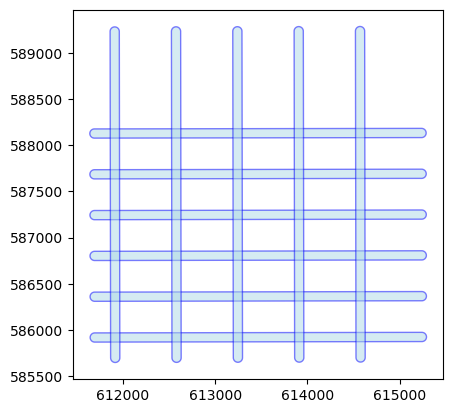

In [26]:
# CREATING THE 50meter BUFFER AROUND THE ROAD
road_buffer = road_utm.copy()
road_buffer['geometry'] = road_utm.buffer(50)

# VISUALISING OF BUFFER
road_buffer.plot(color='lightblue', edgecolor='blue', alpha=0.5)

<Axes: >

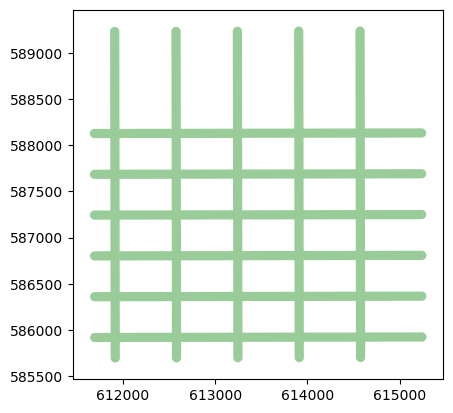

In [27]:
# DISSOLVING BUFFER INTO A SINGLE GEOMETRY
road_buffer_dissolve = road_buffer.dissolve()

# VISUALISING THE DISSOLVED BUFFER
road_buffer_dissolve.plot(color='green', alpha=0.4)

In [28]:
# CALCULATING THE TOTAL AREA OF THE CORRIDOR ROAD IN HECTARES
total_area_m2 = road_buffer_dissolve.area.sum()
total_area_ha = total_area_m2 / 10000

print(f'The Total Area Of The Corridor road is, {total_area_ha:.2f} Hectares')

The Total Area Of The Corridor road is, 368.29 Hectares


QUESTION 3.j

In [29]:
buildings.crs # CHECKING BUILDING CRS

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [30]:
#CHANGING BUILDING CRS TO METERS
buildings_utm = buildings.to_crs(epsg=32630)
print('The crs of buildings is changed to ', buildings_utm.crs)
buildings_utm.crs

The crs of buildings is changed to  EPSG:32630


<Projected CRS: EPSG:32630>
Name: WGS 84 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°W and 0°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Burkina Faso. Côte' Ivoire (Ivory Coast). Faroe Islands - offshore. France. Ghana. Gibraltar. Ireland - offshore Irish Sea. Mali. Mauritania. Morocco. Spain. United Kingdom (UK).
- bounds: (-6.0, 0.0, 0.0, 84.0)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [31]:
# PEFORMING SPATIAL JOIN WITH LAND PARCEL AND BUILDINGS
parcel_with_building = gdp.sjoin(land_parcels_utm,buildings_utm, how='inner', predicate='intersects')

In [32]:
# TOTAL NUMBER OF LAND PARCELS
total_parcel_counts = len(land_parcels_utm)

# TOTAL NUMBER OF PARCELS WITH BUILDINGS
parcel_with_building_count = len(parcel_with_building)

# TOTAL NUMBER OF PARCELS WITHOUT BUILDING WILL BE THE DIFFERENCE BETWEEN THE TWO ABOVE
count_without_buildings = total_parcel_counts - parcel_with_building_count 

# PRINTING THE RESULTS
print(f'Total number of parcels is: {total_parcel_counts}')
print(f'The total number of parcels with buildings is: {parcel_with_building_count}')
print(f'The total number of parcels without building is: {count_without_buildings}')

Total number of parcels is: 48
The total number of parcels with buildings is: 36
The total number of parcels without building is: 12


QUESTION 3.k

In [33]:
# LAND PARCELS THAT INTERSECT WITH 50 METERS ROAD BUFFER
parcels_in_buffer = gdp.sjoin(land_parcels_utm, road_buffer_dissolve, how='inner', predicate='intersects')

# TOTAL NUMBER OF PARCELS THAT INTERSECT WITH TH 50METER BUFFER
count_parcels_in_buffer = len(parcels_in_buffer)
print(f'Number of parcels intersecting the 50m road buffer: {count_parcels_in_buffer}')

# DISPLAYING THE SPECIFIC PAARCELS INTERSECTING WITH THE ROAD
parcels_in_buffer[['parcel_id', 'owner_name', 'land_use']].head()

Number of parcels intersecting the 50m road buffer: 46


,parcel_id,owner_name,land_use
0,TWKP-0001,Kweku Quaye,Agricultural
1,TWKP-0002,Akua Asante,Residential
2,TWKP-0003,Esi Boateng,Commercial
3,TWKP-0004,Ama Amoah,Agricultural
4,TWKP-0005,Esi Frimpong,Agricultural


QUESTION 4.l

In [34]:
!pip install matplotlib-scalebar

In [35]:
from matplotlib_scalebar.scalebar import ScaleBar

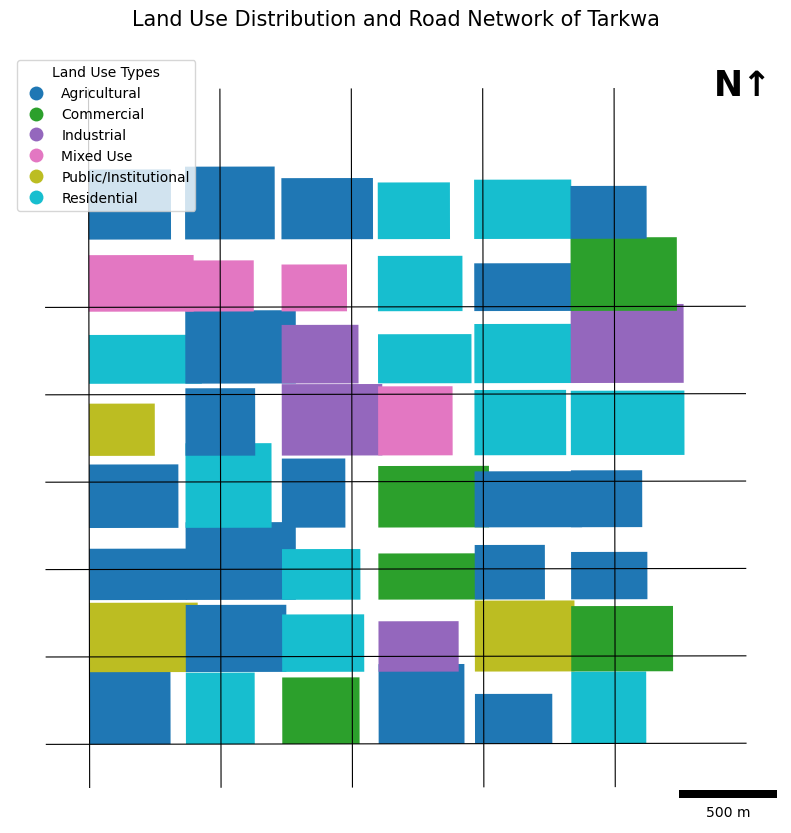

In [36]:
# SETTING UP THE FIGURE AND AXIS
fig, ax = plt.subplots(figsize=(12, 10))

#PLOTING THE CHOROPLETH
land_parcels_utm.plot(column='land_use', ax=ax, cmap='tab10', legend=True,
                      legend_kwds={'title': 'Land Use Types', 'loc':'upper left'})

# OVERLAYING THE ROAD NETWORK
road_utm.plot(ax=ax, color='black', linewidth=0.8, label='Road Network')

#ADDING TITLES AND LABELS
plt.title('Land Use Distribution and Road Network of Tarkwa', fontsize=15, pad=20)
ax.set_axis_off()

#ADDING NORTH ARROW 
ax.text(0.95, 0.98, 'N↑', transform=ax.transAxes, fontsize=25, fontweight='bold', 
        ha='center', va='top')

# ADDING SCALE BAR
scalebar =  ScaleBar(1, 'm', length_fraction=0.15, location='lower right')
ax.add_artist(scalebar)

plt.show()

QUESTION 4.m

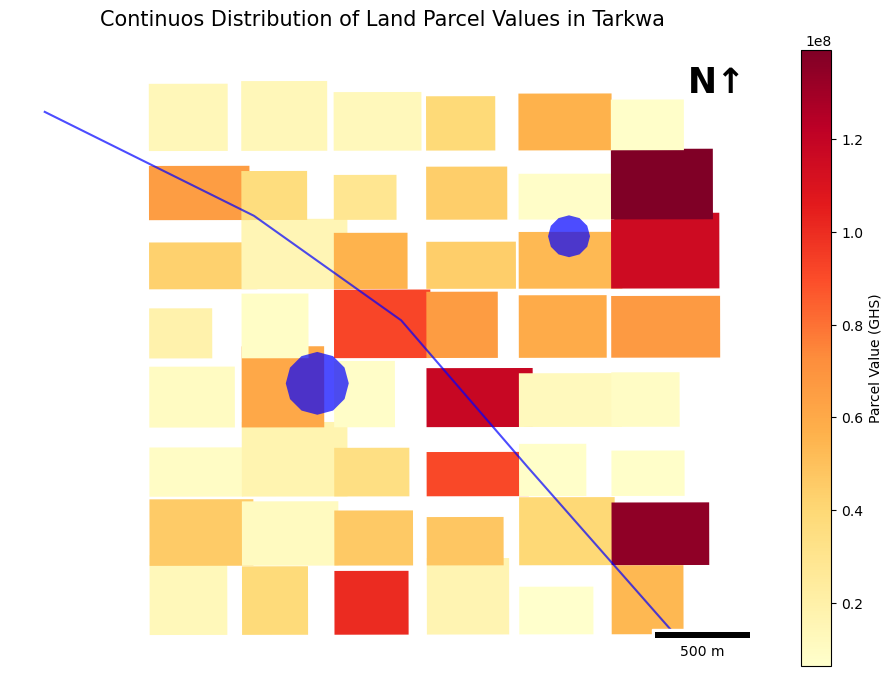

In [37]:
# Setting up the figure and axis 
fig, ax = plt.subplots(figsize=(12,10))

# PLOTTING THE CHOLOROPLETH 
land_parcels_utm.plot(column='value_GHS', ax=ax, cmap='YlOrRd', legend=True, 
                      legend_kwds={'label': 'Parcel Value (GHS)', 'orientation': 'vertical', 'shrink': 0.8 })

# OVERLAYING WATER BODIES
water_bodies = gdp.read_file('water_bodies.geojson')
water_bodies_utm = water_bodies.to_crs(epsg=32630)
water_bodies_utm.plot(ax=ax, color='blue', alpha=0.7, label='Water Bodies')

#ADDING TITLES
plt.title('Continuos Distribution of Land Parcel Values in Tarkwa', fontsize=15, pad=20)
ax.set_axis_off()

#ADDING NORTH ARROW
ax.text(0.95, 0.98, 'N↑', transform=ax.transAxes, fontsize=25, fontweight='bold', ha='center', va='top')

# ADDING SCALE BAR
scalebar = ScaleBar(1, 'm', length_fraction=0.15, location='lower right')
ax.add_artist(scalebar)

plt.show()

PART B

In [38]:
# IMPORTING THE REQUIERED LIBRARIES
import numpy as np
import json

In [39]:
# LOADING AND PRINTING THE TARKWA_MULTISPECTRAL 
data = np.load('tarkwa_multispectral.npz')
print(data.files)
print(data['B2'])
print(data['lc_mask'])

['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'lc_mask']
[[0.02715901 0.05409793 0.02121535 ... 0.07096147 0.09249562 0.08351963]
 [0.00737868 0.04516139 0.05248615 ... 0.08156681 0.09100856 0.06138224]
 [0.0518982  0.02631385 0.03755662 ... 0.08471769 0.06834336 0.06672546]
 ...
 [0.         0.18163978 0.19524832 ... 0.08971067 0.06547126 0.06287228]
 [0.1717725  0.17210025 0.17371747 ... 0.10118119 0.07971761 0.06579737]
 [0.16934673 0.         0.1747056  ... 0.08747444 0.07925856 0.08356683]]
[[1 1 1 ... 2 2 2]
 [1 1 1 ... 2 2 2]
 [1 1 1 ... 2 2 2]
 ...
 [0 4 4 ... 5 5 5]
 [4 4 4 ... 5 5 5]
 [4 0 4 ... 5 5 5]]


In [40]:
# ASSIGNING THE BANDS TO THEIR VARIABLES
blue_band, green_band, red_band = data['B2'], data['B3'], data['B4']
NIR_band, SWIR_1_band, SWIR_2_band = data['B5'], data['B6'], data['B7']

QUESTION 5.n

In [41]:
# CALCULATING NORMALIZE DIFFERENCE VEGETATION INDEX (NEAR INFRA RED - RED) / (NEAR INFRA RED + RED)
NDVI = (NIR_band - red_band) / (NIR_band + red_band + 1e-10)
print(f'The calculated mean value for the NDVI is: {np.mean(NDVI):.3f}')
print(f'The calculated minimum value for the NDVI is: {np.min(NDVI):.3f}')
print(f'The calculated maximum value for NDVI is: {np.max(NDVI):.3f}')

The calculated mean value for the NDVI is: 0.147
The calculated minimum value for the NDVI is: -0.885
The calculated maximum value for NDVI is: 0.977


QUESTION 5.o

In [42]:
# CALCULATING THE NORMALIZE DIFFERENCE WATER INDEX (GREEN - NEAR INFRA RED) / (GREEN + NEAR INFRA RED)
NDWI = (green_band - NIR_band) / (green_band + NIR_band + 1e-10)
print(f'The calculated mean value for the NDWI is: {np.mean(NDWI):.3f}')
print(f'The calculated minimum value for the NDWI is: {np.min(NDWI):.3f}')
print(f'The calculated maximum value for NDWI is: {np.max(NDWI):.3f}')

The calculated mean value for the NDWI is: -0.138
The calculated minimum value for the NDWI is: -0.928
The calculated maximum value for NDWI is: 0.915


QUESTION 5.p

In [43]:
# CALCULATING THE NORMALIZE DIFFERENCE BUILT-UP INDEX 
#(SHORT WAVE INFRA RED1 - NEAR INFRA RED) / (SHORT WAVE INFRA RED1 + NEAR INFRA RED)
NDBI = (SWIR_1_band - NIR_band) / (SWIR_1_band + NIR_band + 1e-10)
print(f'The calculated mean value for the NDBI is: {np.mean(NDBI):.3f}')
print(f'The calculated minimum value for the NDBI is: {np.min(NDBI):.3f}')
print(f'The calculated maximum value for NDBI is: {np.max(NDBI):.3f}')

The calculated mean value for the NDBI is: -0.023
The calculated minimum value for the NDBI is: -0.822
The calculated maximum value for NDBI is: 0.851


QUESTION 5.q

In [44]:
# CALCULATING THE SOIL ADJUSTED VEGETATION INDEX ((NEAR INFRA RED - RED) / (NEAR INFRA RED + RED + 0.5)) * 1.5
SAVI = ((NIR_band - red_band) / (NIR_band + red_band + 0.5)) * 1.5
print(f'The calculated mean value for the SAVI is: {np.mean(SAVI):.3f}')
print(f'The calculated minimum value for the SAVI is: {np.min(SAVI):.3f}')
print(f'The calculated maximum value for SAVI is: {np.max(SAVI):.3f}')

The calculated mean value for the SAVI is: 0.151
The calculated minimum value for the SAVI is: -0.197
The calculated maximum value for SAVI is: 0.675


QUESTION 5.r

In [45]:
# CALCULATING THE NORMALIZED BURNED RATIO (NEAR INFRA RED - SHORT WAVE INFRA RED2) / (NEAR INFRA RED + SHORT WAVE INFRA RED2)
NBR = (NIR_band - SWIR_2_band) / (NIR_band + SWIR_2_band + 1e-10)
print(f'The calculated mean value for the NBR is: {np.mean(NBR):.3f}')
print(f'The calculated minimum value for the NBR is: {np.min(NBR):.3f}')
print(f'The calculated maximum value for NBR is: {np.max(NBR):.3f}')

The calculated mean value for the NBR is: 0.141
The calculated minimum value for the NBR is: -0.852
The calculated maximum value for NBR is: 0.822


QUESTION 6.s

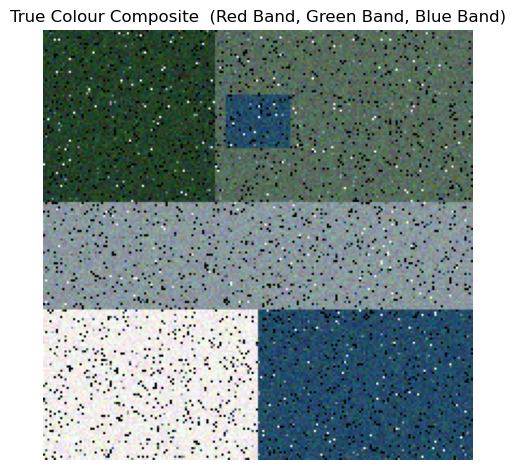

In [ ]:
# HISTOGRAM STRECHING AND CLIPING TO 2nd TO 98th PERCENTILE
def histogram_stretch(band):
    p2 = np.percentile(band, 2)
    p98 = np.percentile(band, 98)
    stretched = (band - p2) / (p98 - p2)
    return np.clip(stretched, 0, 1)

# STACKING INTO (200, 200, 3) ARRAY
tcc = np.stack([histogram_stretch(red_band), histogram_stretch(green_band),
                 histogram_stretch(blue_band)], axis=-1)

# DISPLAYING THE RESULTS
plt.Figure(figsize=(6, 6))
plt.imshow(tcc)
plt.title('True Colour Composite  (Red Band, Green Band, Blue Band)')
plt.axis('off')
plt.tight_layout()

plt.show()


QUESTION 6.t

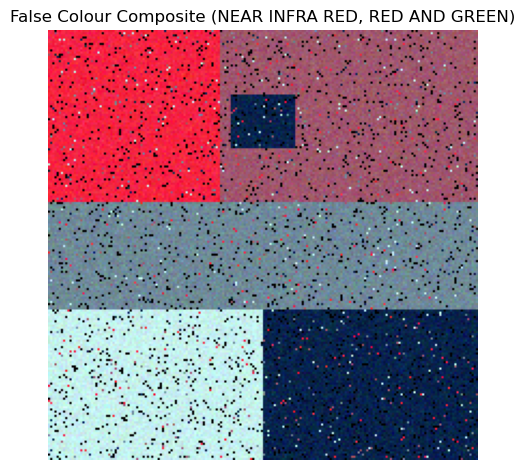

In [54]:
# DISPLAYING A FALSE COLOUR COMPOSITE FOR NEAR INFRA RED, RED AND GREEN
fcc = np.stack([histogram_stretch(NIR_band), histogram_stretch(red_band), 
               histogram_stretch(green_band)], axis=-1)
plt.Figure(figsize=(6, 6))
plt.imshow(fcc)
plt.title('False Colour Composite (NEAR INFRA RED, RED AND GREEN)')
plt.axis('off')
plt.tight_layout()
plt.show()

QUESTION 6.u

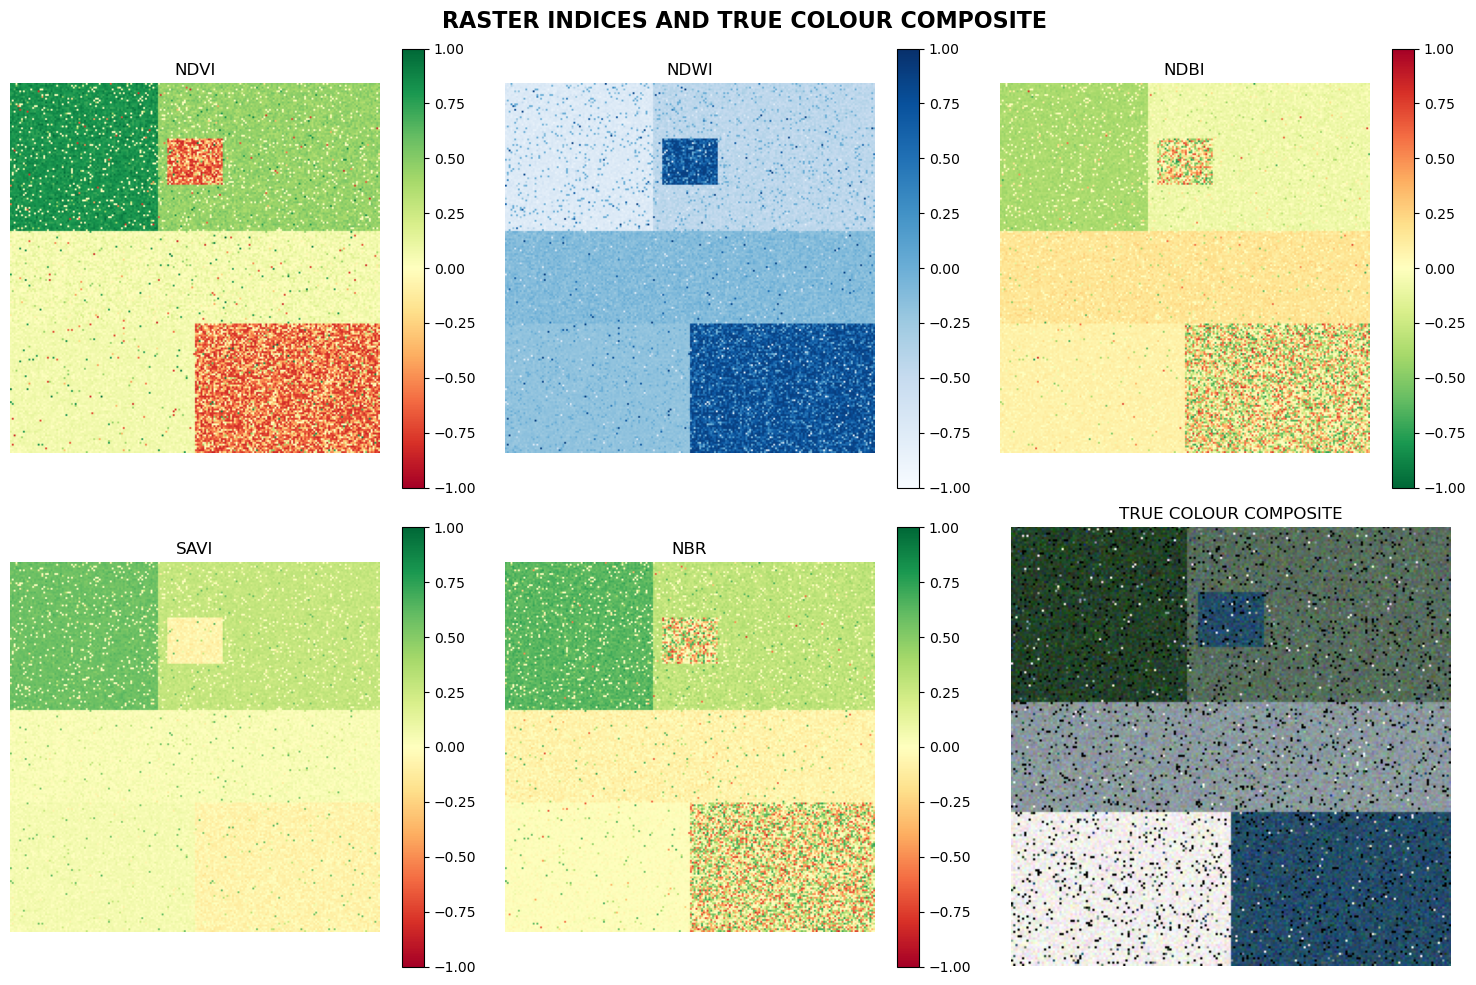

In [70]:
# CREATING A 2 BY 3 SUBPLOT
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

#SUBPLOT FOR NDVI
im0 = axes[0, 0].imshow(NDVI, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0, 0].set_title('NDVI')
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0])

#SUBPLOT FOR NDWI
im1 = axes[0, 1].imshow(NDWI, cmap='Blues', vmin=-1, vmax=1)
axes[0, 1].set_title('NDWI')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1])

#SUBPLOT FOR NDBI
im2 = axes[0, 2].imshow(NDBI, cmap='RdYlGn_r', vmin=-1, vmax=1)
axes[0, 2].set_title('NDBI')
axes[0, 2].axis('off')
plt.colorbar(im2, ax=axes[0, 2])

#SUBPLOT FOR SAVI
im3 = axes[1, 0].imshow(SAVI, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1, 0].set_title('SAVI')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0])

#SUBPLOT FOR NBR
im4 = axes[1, 1].imshow(NBR, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1, 1].set_title('NBR')
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1])

#SUBPLOT FOR TH TRUE COLOUR COMPOSITE
axes[1, 2].imshow(tcc)
axes[1, 2].set_title('TRUE COLOUR COMPOSITE')
axes[1, 2].axis('off')

plt.suptitle('RASTER INDICES AND TRUE COLOUR COMPOSITE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

QUESTION 7.v

In [77]:
# CREATING AN EMPTY ARRAY SAME SHAPE AS NDVI
classification = np.zeros(NDVI.shape, dtype=np.int32)

# CLASS 1: DENSE VEGETATION
classification = np.where((NDVI > 0.30) & (NDVI <= 0.30), 2, classification)

# CLASS 2: SPARSE VEGETATION
classification = np.where((NDVI > 0.10) & (NDVI <= 0.30), 2, classification)

#CLASS 3: URBAN OR BUILT UP
classification = np.where((NDBI > 0.1) & (NDVI <= 0.10), 3, classification)

#CLASS 4: BARE SOIL
classification = np.where((NDVI <= 0.10) & (NDBI <= 0.10) & (NDWI <= 0), 4, classification)

# CLASS 5: WATER
classification = np.where(NDWI > 0.1, 5, classification)

# DICTIONARY MAPPING OF CLASS NUMBERS TO NAMES
class_labels = {1: 'Dense Vegetation', 2: 'Sparse Vegetaion', 3: 'Urban / Built-up',
                4: 'Bare Soil', 5: 'water_bodies'}
total_pixels = classification.size
print(f'{'Class':<5} {'Label':<25} {'Count':<10} {'percentage'}')

#LOOPING THROUGTH EACH CLASS NUMBER AND LABEL
for cls, label in class_labels.items():
    count = np.sum(classification == cls)
    pct = (count / total_pixels) * 100
    print(f'{cls:<5} {label:<25} {count:<10} {pct:.2f}%')


Class Label                     Count      percentage
1     Dense Vegetation          0          0.00%
2     Sparse Vegetaion          2754       6.88%
3     Urban / Built-up          9023       22.56%
4     Bare Soil                 6359       15.90%
5     water_bodies              7348       18.37%


QUESTION 7.w

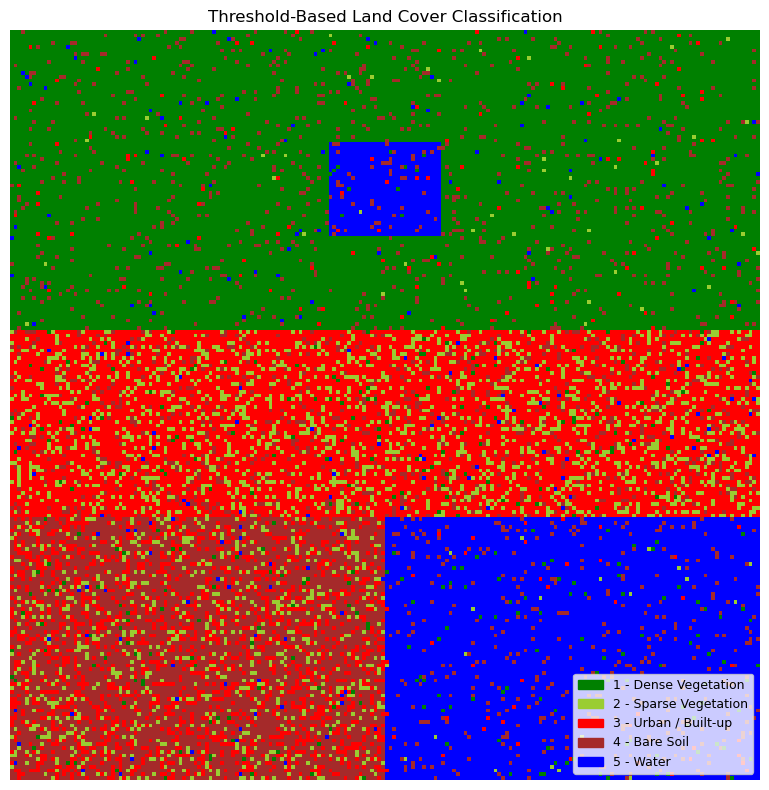

In [80]:
import matplotlib.patches as mpatches          # for creating legend colour boxes
from matplotlib.colors import ListedColormap, BoundaryNorm  # for discrete colours

#Defining the classes
colors = ['green',        # Class 1 - Dense Vegetation
          'yellowgreen',  # Class 2 - Sparse Vegetation
          'red',          # Class 3 - Urban / Built-up
          'brown',        # Class 4 - Bare Soil
          'blue']         # Class 5 - Water
cmap = ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm   = BoundaryNorm(bounds, cmap.N)

# Create a figure canvas for the plot
plt.figure(figsize=(8, 8))

# Display the classification
plt.imshow(classification, cmap=cmap, norm=norm)
plt.title('Threshold-Based Land Cover Classification')
plt.axis('off')
legend_patches = [
    mpatches.Patch(color='green',       label='1 - Dense Vegetation'),
    mpatches.Patch(color='yellowgreen', label='2 - Sparse Vegetation'),
    mpatches.Patch(color='red',         label='3 - Urban / Built-up'),
    mpatches.Patch(color='brown',       label='4 - Bare Soil'),
    mpatches.Patch(color='blue',        label='5 - Water')
]
plt.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

QUESTION 7.x

Overall Accuracy: 49.34%

Confusion Matrix:
[[   0    0    0    0    0]
 [   0   14    0    0    0]
 [   0 1906 7275  257    0]
 [   0  834 1748 4126    0]
 [   0    0    0    2 7348]]


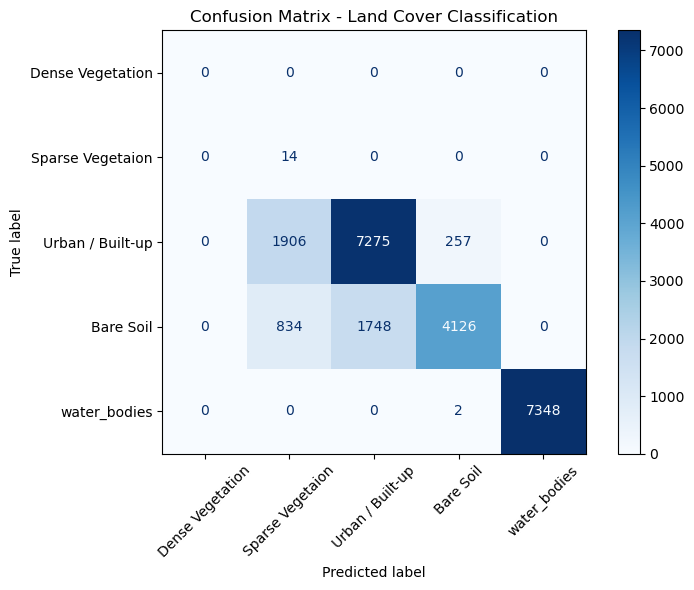

In [85]:
#Importing evaluation metrics 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Loading the ground truth land cover array
lc_mask = data['lc_mask']

# Flattenning the arrays
lc_flat   = lc_mask.flatten()
pred_flat = classification.flatten()

valid     = lc_flat > 0           # Boolean mask: True where label exists
lc_valid  = lc_flat[valid]        # Keep only valid ground truth pixels
pred_valid = pred_flat[valid]     # Keep matching predicted pixels

# Overall Accuracy
overall_accuracy = np.sum(lc_valid == pred_valid) / len(lc_valid) * 100
print(f"Overall Accuracy: {overall_accuracy:.2f}%")

# Confusion Matrix
labels = [1, 2, 3, 4, 5]
cm = confusion_matrix(lc_valid, pred_valid, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Ploting the  Confusion Matrix as a Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_labels.values()))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Land Cover Classification')
plt.tight_layout()
plt.show()

QUESTION 8.y

In [88]:
# Loading ground truth land cover mask
lc_mask = data['lc_mask']

# Dictionary mapping class numbers to their names
class_labels = {
    1: 'Dense Vegetation', 2: 'Sparse Vegetation', 3: 'Urban / Built-up',  4: 'Bare Soil', 5: 'Water'}

# Printing formatted table header
print(f"{'Class':<5} {'Label':<25} {'Mean NDVI':<15} {'Physical Sense'}")


# Looping through each class
for cls, label in class_labels.items():
    mask = lc_mask == cls     # Create a boolean mask
    ndvi_values = NDVI[mask]     # Use the mask to extract NDVI values for this class only
    mean_ndvi = np.mean(ndvi_values)    # Calculate mean NDVI for this class
    print(f"{cls:<5} {label:<25} {mean_ndvi:<15.3f}", end="")   #Printing one row per class with 3 decimal places for mean NDVI
    if cls == 1:
        print(" High NDVI expected - healthy dense vegetation absorbs red, reflects NIR")
    elif cls == 2:
        print(" Moderate NDVI expected - less leaf coverage than dense vegetation")
    elif cls == 3:
        print(" Low NDVI expected - concrete/buildings reflect red, absorb NIR")
    elif cls == 4:
        print(" Very low NDVI expected - bare soil has little vegetation activity")
    elif cls == 5:
        print(" Negative/near-zero NDVI expected - water absorbs NIR strongly")

Class Label                     Mean NDVI       Physical Sense
1     Dense Vegetation          0.820           High NDVI expected - healthy dense vegetation absorbs red, reflects NIR
2     Sparse Vegetation         0.446           Moderate NDVI expected - less leaf coverage than dense vegetation
3     Urban / Built-up          0.059           Low NDVI expected - concrete/buildings reflect red, absorb NIR
4     Bare Soil                 0.067           Very low NDVI expected - bare soil has little vegetation activity
5     Water                     -0.531          Negative/near-zero NDVI expected - water absorbs NIR strongly


QUESTION 8.z

In [92]:
# Identifying  Mining Areas in Tarkwa
mining_mask = (NDVI < 0.05) & (NDBI > 0.05)

# Counting the number of True values in the mask
mining_pixel_count = np.sum(mining_mask)
print(f"Number of mining/degraded pixels: {mining_pixel_count}")


# Calculating The Total Area
pixel_area_m2 = 900  # m^2 per pixel (30m by 30m) 
total_area_m2 = mining_pixel_count * pixel_area_m2 # Total area in square metres
total_area_ha = total_area_m2 / 10000 # Converting to hectares

print(f"\nMining / Degraded Land Area")
print(f"Pixel Count     : {mining_pixel_count} pixels")
print(f"Total Area (m^2) : {total_area_m2:,} m^2")      # comma separator for thousands
print(f"Total Area (ha) : {total_area_ha:.2f} hectares")

Number of mining/degraded pixels: 8907

Mining / Degraded Land Area
Pixel Count     : 8907 pixels
Total Area (m^2) : 8,016,300 m^2
Total Area (ha) : 801.63 hectares
